In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import pandas as pd

import sys

sys.path.append('T:\EL_experiment\Codes\CCEP_human\Python_Analysis/py_functions')

from scipy.stats import norm
from tkinter import *
import scipy
from scipy import signal

import platform
from glob import glob
from scipy.spatial import distance
import basic_func as bf
from scipy.integrate import simps
from numpy import trapz
import tqdm
from matplotlib.patches import Rectangle
from pathlib import Path
import statsmodels.api as sm
import statsmodels.formula.api as smf

#
from scipy.signal import hilbert, butter, filtfilt
import scipy.stats as stats
from tqdm.notebook import trange, tqdm
import load_summary as ls
cwd             = os.getcwd()

##all 
cond_vals   = np.arange(4)
cond_labels = ['BM', 'BL', 'Fuma', 'Benzo']
cond_colors = ['#494159','#594157', "#F1BF98","#8FB996"]
dist_groups = np.array([[0,15],[15,30],[30,5000]])
dist_labels = ['local (<15 mm)', 'short (<30mm)', 'long']
sub_path  ='X:\\4 e-Lab\\' # y:\\eLab

sys.path.append('T:\\EL_experiment\Codes\CCEP_human\Python_Analysis\py_functions')

In [2]:
import load_summary as ls
sub_path  ='X:\\4 e-Lab\\' # y:\\eLab
subjs = ["EL010", "EL011", "EL013", "EL014", "EL015", "EL016", "EL019", "EL020", "EL021",
         "EL022", "EL024", "EL026", "EL027", "EL028"]

### Load Stimlists with sleep stages

In [3]:
from sklearn.metrics import confusion_matrix, cohen_kappa_score, accuracy_score

In [4]:
# Initialize an empty DataFrame with the desired columns
df = pd.DataFrame(columns=['subj', 'Kappa', 'Accuracy', 'Acc. Wake', 'Acc. NREM', 'Acc. REM'])

for ix_subj, subj in enumerate(subjs):
    path_patient_analysis = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', subj)
    file = os.path.join(path_patient_analysis, 'stimlist_hypnogram.csv')
    stimlist_hypno = pd.read_csv(file)
    # remove times where artefacts or seizures are stored(Paivi did it in scoring, I did it in epitome as bad times)
    stimlist_hypno.loc[stimlist_hypno.sleep > 4, 'sleep'] = np.nan
    stimlist_hypno.loc[stimlist_hypno.score_clinic > 4, 'score_clinic'] = np.nan
    valid_scores = stimlist_hypno.dropna(subset=['score_clinic', 'sleep']).reset_index(drop=True)
    acc = accuracy_score(valid_scores['score_clinic'].astype(int), valid_scores['sleep'].astype(int))
    kappa = cohen_kappa_score(valid_scores['score_clinic'].astype(int), valid_scores['sleep'].astype(int))
    
    # Convert 'Time' column to datetime
    valid_scores['Time'] = pd.to_datetime(valid_scores['Time'])

    # Set 'Time' as the index
    valid_scores.set_index('Time', inplace=True)

    # Resample and aggregate
    result_df = valid_scores.resample('30S').agg(lambda x: x.mode()[0] if not x.empty else None)

    # Reset index if you want 'Time' back as a column
    result_df.reset_index(inplace=True)
    result_df = result_df.dropna(subset=['score_clinic', 'sleep']).reset_index(drop=True)
    kappa = cohen_kappa_score(result_df['score_clinic'].astype(int), result_df['sleep'].astype(int))
    acc = accuracy_score(result_df['score_clinic'].astype(int), result_df['sleep'].astype(int))

    valid_scores.loc[valid_scores.sleep ==2, 'sleep'] = 3
    valid_scores.loc[valid_scores.score_clinic ==2, 'score_clinic'] = 3
    acc_sub = np.zeros((3,))
    for ix, val in enumerate([0, 3, 4]): 
        score1 = valid_scores.sleep.values.copy()
        score1[score1 != val] = -1
        score2 = valid_scores.score_clinic.values.copy()
        score2[score2 != val] = -1
        acc_sub[ix] = accuracy_score(score1, score2)
    # Append the new row to the DataFrame
    df = df.append({
        'subj': subj,
        'Kappa': kappa,
        'Accuracy': acc,
        'Acc. Wake': acc_sub[0],
        'Acc. NREM': acc_sub[1],
        'Acc. REM': acc_sub[2]
    }, ignore_index=True)


In [5]:
path_patient_analysis = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', subj)
file = os.path.join(path_patient_analysis, 'stimlist_hypnogram.csv')
stimlist_hypno = pd.read_csv(file)
stimlist_hypno.loc[stimlist_hypno.sleep > 4, 'sleep'] = np.nan
stimlist_hypno.loc[stimlist_hypno.score_clinic > 4, 'score_clinic'] = np.nan

In [6]:
df = stimlist_hypno.dropna(subset=['score_clinic', 'sleep']).reset_index(drop=True)
# Convert 'Time' column to datetime
df['Time'] = pd.to_datetime(df['Time'])

# Set 'Time' as the index
df.set_index('Time', inplace=True)

# Resample and aggregate
result_df = df.resample('30S').agg(lambda x: x.mode()[0] if not x.empty else None)

# Reset index if you want 'Time' back as a column
result_df.reset_index(inplace=True)
result_df = result_df.dropna(subset=['score_clinic', 'sleep']).reset_index(drop=True)
kappa = cohen_kappa_score(result_df['score_clinic'].astype(int), result_df['sleep'].astype(int))
kappa

0.7253996122706556

In [7]:
valid_scores = stimlist_hypno.dropna(subset=['score_clinic', 'sleep']).reset_index(drop=True)
kappa = cohen_kappa_score(valid_scores['score_clinic'].astype(int), valid_scores['sleep'].astype(int))
kappa

0.7378552130810947

In [52]:
# Ensure 'Time' is the DataFrame index if not already
if 'Time' in result_df.columns:
    result_df.set_index('Time', inplace=True)
    
# Ensure 'Time' is the DataFrame index if not already
if 'Time' in valid_scores.columns:
    valid_scores.set_index('Time', inplace=True)

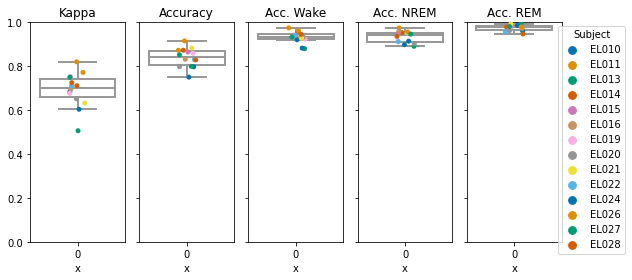

In [59]:
metrics = ['Kappa', 'Accuracy', 'Acc. Wake', 'Acc. NREM', 'Acc. REM']
fig, axes = plt.subplots(1, len(metrics), figsize=(8, 4), sharey=True)  # Adjusted for better visualization

# Define a color palette for the stripplot
palette = sns.color_palette('colorblind', n_colors=df['subj'].nunique())

unique_subjects = df['subj'].nunique()
palette = sns.color_palette('colorblind', n_colors=unique_subjects)
df['x'] = 0
for i, metric in enumerate(metrics):
    sns.boxplot(y=metric, data=df, ax=axes[i], color='white', linewidth=2, fliersize=0)
    sns.stripplot(x='x', y=metric, data=df, ax=axes[i], hue='subj', palette=palette, dodge=False, jitter=True, alpha=1.)
    # sns.scatterplot(y=metric, data=df, ax=axes[i], hue='subj', palette=palette, s= 10)
    axes[i].set_ylim([0, 1])
    axes[i].set_ylabel('')
    axes[i].set_title(metric)

    # Hide legend for all but the last plot
    # Check if the legend was created and remove it
    legend = axes[i].get_legend()
    if legend:
        legend.remove()

# Adjust legend to show on the right
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.1, 0.5), title='Subject')

plt.tight_layout()  # Adjust layout to not overlap
plt.show()

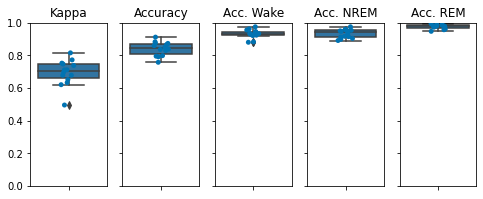

In [70]:
metrics = ['Kappa', 'Accuracy', 'Acc. Wake', 'Acc. NREM', 'Acc. REM']

# Create a 1x3 subplot structure
fig, axes = plt.subplots(1, len(metrics), figsize=(8, 3), sharey=True)  # Adjust figsize as needed

# Loop through each selection and plot on the respective axes
for i, x in enumerate(metrics):
    sns.boxplot(y=x, data=df, ax=axes[i])
    sns.stripplot(y=x, data=df, ax=axes[i], hue='subj', palette='colorblind')
    axes[i].set_ylim([0,1])
    axes[i].set_ylabel('')
    axes[i].set_title(x)

In [ ]:
# Create a 1x3 subplot structure
fig, axes = plt.subplots(1, 5, figsize=(8, 3))  # Adjust figsize as needed

# Loop through each selection and plot on the respective axes
for i, (x, xlab) in enumerate(zip(x_sel, x_labels)):
    sns.histplot(x=x, data=df_WM, hue='WM_tract', multiple='fill', ax=axes[i], bins = 50)
    axes[i].set_xlabel(xlab)
    axes[i].set_ylabel('Count')  # Add y-label if needed

plt.tight_layout()  # Adjust subplots to fit into figure area nicely
plt.show()

In [112]:
# Initialize an empty DataFrame with the desired columns
df = pd.DataFrame(columns=['subj', 'n_blocks', 'Wake', 'NREM', 'REM'])

for ix_subj, subj in enumerate(subjs):
    path_patient_analysis = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', subj)
    file = os.path.join(path_patient_analysis, 'stimlist_hypnogram.csv')
    stimlist = pd.read_csv(file)
    stimlist = add_sleepstate(stimlist)
    n_blocks = np.max(stimlist['stim_block'])
    count_total = len(stimlist)
    # Calculate counts and percentages
    count_wake = len(stimlist[stimlist['SleepState'] == 'Wake'])
    wake_info = count_wake/count_total*100 # 3f'{count_wake} ({count_wake/count_total*100:0.2f}%)'
    
    count_nrem = len(stimlist[stimlist['SleepState'] == 'NREM'])
    nrem_info = count_nrem/count_total*100 #f'{count_nrem} ({count_nrem/count_total*100:0.2f}%)'
    
    count_rem = len(stimlist[stimlist['SleepState'] == 'REM'])
    rem_info = count_rem/count_total*100 #f'{count_rem} ({count_rem/count_total*100:0.2f}%)'
    
    # Append the new row to the DataFrame
    df = df.append({
        'subj': subj,
        'n_blocks': n_blocks,
        'Wake': wake_info,
        'NREM': nrem_info,
        'REM': rem_info
    }, ignore_index=True)


In [118]:
md

67.57314007586969

In [123]:
for ss in ['Wake', 'NREM', 'REM']:
    md = np.median(df[ss])
    i2 = np.quantile(df[ss], 0.25)
    i4 = np.quantile(df[ss], 0.75)
    print(f'{md:0.2f}\% [{i2:0.2f},{i4:0.2f}]')

67.57\% [61.87,76.94]
18.81\% [15.75,25.97]
5.11\% [2.77,8.17]


In [109]:
# Initialize an empty DataFrame with the desired columns
df = pd.DataFrame(columns=['ID', '# Block', 'Wake', 'NREM', 'REM'])

for ix_subj, subj in enumerate(subjs):
    path_patient_analysis = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', subj)
    file = os.path.join(path_patient_analysis, 'stimlist_hypnogram.csv')
    stimlist = pd.read_csv(file)
    stimlist = add_sleepstate(stimlist)
    n_blocks = np.max(stimlist['stim_block'])
    count_total = len(stimlist)
    # Calculate counts and percentages
    count_wake = len(stimlist[stimlist['SleepState'] == 'Wake'])
    wake_info = f'{count_wake} ({count_wake/count_total*100:0.2f}%)'
    
    count_nrem = len(stimlist[stimlist['SleepState'] == 'NREM'])
    nrem_info = f'{count_nrem} ({count_nrem/count_total*100:0.2f}%)'
    
    count_rem = len(stimlist[stimlist['SleepState'] == 'REM'])
    rem_info = f'{count_rem} ({count_rem/count_total*100:0.2f}%)'
    
    # Append the new row to the DataFrame
    df = df.append({
        'ID': subj,
        '# Block': n_blocks,
        'Wake': wake_info,
        'NREM': nrem_info,
        'REM': rem_info
    }, ignore_index=True)


In [111]:
# Convert the DataFrame to LaTeX format and save it to a file
latex_table = df.to_latex(index=False, longtable=True)

file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\patients\\sleep_blocks.tex'
with open(file, 'w') as file:
    file.write(latex_table)


In [99]:
def add_sleepstate(con_trial):
    if not 'SleepState' in con_trial:
        con_trial.insert(6, 'SleepState', 'Wake')
    if not 'Ictal' in con_trial:
        con_trial.insert(6, 'Ictal', 0)
    con_trial.loc[(con_trial.SleepState == 'W'), 'SleepState'] = 'Wake'
    con_trial.loc[(con_trial.sleep == 0), 'SleepState'] = 'Wake'
    con_trial.loc[(con_trial.sleep > 1) & (con_trial.sleep < 4), 'SleepState'] = 'NREM'
    con_trial.loc[(con_trial.sleep == 1), 'SleepState'] = 'NREM1'
    con_trial.loc[(con_trial.sleep == 6), 'SleepState'] = 'SZ'
    con_trial.loc[(con_trial.sleep == 4), 'SleepState'] = 'REM'
    con_trial.loc[(con_trial.sleep == 5), 'SleepState'] = 'Unknown'
    con_trial.loc[(con_trial.Ictal != 0), 'SleepState'] = 'SZ'
    return con_trial

In [74]:
prot = 'InputOutput'
count = len(stimlist[stimlist.Prot ==prot])

,ix_h,ix,Prot,StimNum,h,s,min,ChanP,Int_prob,date,sleep,stim_block
0,17.633889,0,InputOutput,0,17,2,38,38,4.0,20210126,0,1
1,17.649444,1,InputOutput,1,17,58,38,38,12.0,20210126,0,1
2,17.638333,2,InputOutput,2,17,18,38,6,6.0,20210126,0,1
3,17.638333,3,InputOutput,3,17,18,38,6,1.0,20210126,0,1
4,17.641389,4,InputOutput,4,17,29,38,42,0.2,20210126,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
18431,8.956667,18431,InputOutput,7199,8,24,57,22,3.0,20210128,0,40
18432,8.957222,18432,InputOutput,7200,8,26,57,22,4.0,20210128,0,40
18433,8.955278,18433,InputOutput,7201,8,19,57,38,0.6,20210128,0,40
18434,8.960278,18434,InputOutput,7202,8,37,57,42,3.0,20210128,0,40


In [62]:
import os
import pandas as pd
import numpy as np
import re

# Assuming 'subjs', 'sub_path', 'regions_all', and 'atlas' are already defined
# Also assuming 'bf.get_Stim_chans' is a function you have access to

arr = []
for ix_s, subj in enumerate(subjs):
    path_patient_analysis = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', subj)
    path_infos = os.path.join(sub_path, 'Patients', subj, 'Electrodes')
    lbls = pd.read_excel(os.path.join(path_infos, subj + "_labels.xlsx"), header=0, sheet_name='BP')
    if "type" in lbls.columns:
        lbls = lbls[lbls.type == 'SEEG'].reset_index(drop=True)
        
    labels_all = lbls.label.values

    
    ix = 0
    for label in labels_all:
        region = atlas.loc[atlas['Extra-Modifier'] == " ".join(re.findall("[a-zA-Z_]+", label)), 'Region'].values
        if len(region)>0:
            if np.isin(region[0], regions_all):
                ix += 1
        else:
            region = atlas.loc[atlas['Abbreviation'] == " ".join(re.findall("[a-zA-Z_]+", label)), 'Region'].values
            if len(region)>0:
                if np.isin(region[0], regions_all):
                    ix += 1
    # Append the accumulated data for each subject to 'arr'
    arr.append([subj, ix, block_number])

# Create the DataFrame after the loop
df = pd.DataFrame(arr, columns=['Subj', 'Num GM', 'Num Block'])


In [63]:
df

,Subj,Num GM,Num Block
0,EL003,40,46
1,EL004,63,46
2,EL005,46,46
3,EL008,34,46
4,EL010,43,46
5,EL011,54,46
6,EL012,77,46
7,EL013,52,46
8,EL014,47,46
9,EL015,56,46


In [27]:
CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
tab_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='plot')
tab_region = tab_region.sort_values('Order').reset_index(drop=True)
regions_all = tab_region.Area.values
region_col = tab_region.color.values

CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
all_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')

In [49]:
CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
atlas = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')


In [51]:
import os
import pandas as pd
import numpy as np
import re

# Assuming 'subjs', 'sub_path', 'regions_all', and 'atlas' are already defined
# Also assuming 'bf.get_Stim_chans' is a function you have access to

arr = []
for ix_s, subj in enumerate(subjs):
    path_patient_analysis = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', subj)
    path_infos = os.path.join(sub_path, 'Patients', subj, 'Electrodes')
    lbls = pd.read_excel(os.path.join(path_infos, subj + "_labels.xlsx"), header=0, sheet_name='BP')
    if "type" in lbls.columns:
        lbls = lbls[lbls.type == 'SEEG'].reset_index(drop=True)
        
    stimlist_file = os.path.join(path_patient_analysis, 'InputOutput', 'CR', 'data', 'stimlist_CR.csv')
    stimlist = pd.read_csv(stimlist_file)
    labels_all, labels_region, labels_clinic, coord_all, StimChans, StimChanSM, StimChansC, StimChanIx, stimlist = bf.get_Stim_chans(
        stimlist,
        lbls)
    block_number = len(np.unique(stimlist.stim_block))
    
    ix = 0
    for label in labels_all:
        region = atlas.loc[atlas['Extra-Modifier'] == " ".join(re.findall("[a-zA-Z_]+", label)), 'Region'].values
        if len(region)>0:
            if np.isin(region[0], regions_all):
                ix += 1
        else:
            region = atlas.loc[atlas['Abbreviation'] == " ".join(re.findall("[a-zA-Z_]+", label)), 'Region'].values
            if len(region)>0:
                if np.isin(region[0], regions_all):
                    ix += 1
    # Append the accumulated data for each subject to 'arr'
    arr.append([subj, ix, block_number])

# Create the DataFrame after the loop
df = pd.DataFrame(arr, columns=['Subj', 'Num GM', 'Num Block'])


In [53]:
df.to_excel('X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\patients\\CR_blocks.xlsx')

In [7]:
arr = []
for ix_s, subj in enumerate(subjs):
    path_patient_analysis = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', subj)
    path_infos = os.path.join(sub_path,'Patients', subj,'Electrodes')
    lbls = pd.read_excel(os.path.join(path_infos, subj + "_labels.xlsx"), header=0, sheet_name='BP')
    if "type" in lbls.columns:
        lbls = lbls[lbls.type=='SEEG']
        lbls = lbls.reset_index(drop=True)
        
    stimlist_file = path_patient_analysis + '\\InputOutput\\CR\\data\\stimlist_CR.csv'
    stimlist = pd.read_csv(stimlist_file)
    labels_all, labels_region, labels_clinic, coord_all, StimChans, StimChanSM, StimChansC, StimChanIx, stimlist = bf.get_Stim_chans(
    stimlist,
    lbls)
    block_number = len(np.unique(stimlist.stim_block))
    
    ix = 0
    for label in labels_all:
        region = atlas.loc[atlas.Abbreviation == " ".join(re.findall("[a-zA-Z_]+",label)), 'Region'].values[0]
        if np.isin(region, regions_all):
            ix = ix+1
    arr = [[subj,ix, block_number,]]
df = pd.DataFrame(arr, columns =['Subj', 'Num GM', 'Num Block']) 